# 🏢 Workforce Intelligence Analytics
## Notebook 02: Data Cleaning & Exploratory Data Analysis (EDA)
**Subtitle:** *Transforming raw employee reviews into an analytics-ready workforce dataset.*

---

### 📌 Analytical Objective & Cleaning Workflow
Raw review data inevitably contains missing strings, invalid datatypes, extraneous whitespace, and varying formats. This notebook establishes a reliable data-cleaning pipeline that transforms raw input records into a validated, typed, and normalized analytical dataset.

```
DATA TRANSFORMATION PIPELINE
┌─────────────────────────┐
│     RAW DATASET         │ (8,785 rows, 31 columns)
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│     QUALITY CHECK       │ Deduplicate reviewId, inspect nulls, validate ratings [1, 5]
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│       CLEANING          │ Normalize strings, parse ISO timestamps, handle missing advice
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│   FEATURE CREATION      │ Combined review_text, char_length, word_count, rating_segment
└───────────┬─────────────┘
            ▼
┌─────────────────────────┐
│    ANALYSIS DATASET     │ data/processed/glassdoor_cleaned.csv
└─────────────────────────┘
```

---
### Section 1: Ingestion & Duplicate Auditing

> **WHAT ARE WE DOING?**  
> We load the raw dataset and verify uniqueness on `reviewId` and across all columns.
>
> **WHY ARE WE DOING IT?**  
> Duplicate reviews can artificially inflate topic prevalence or bias company sentiment metrics.
>
> **WHAT SHOULD WE EXPECT?**  
> All 8,785 reviews are unique by `reviewId` (0 duplicate rows).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('.').resolve().parent
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

csv_path = list(DATA_RAW.glob('*.csv'))[0]
df = pd.read_csv(csv_path)

print(f"Initial row count: {len(df):,}")
dupes_id = df['reviewId'].duplicated().sum()
dupes_all = df.duplicated().sum()
print(f"Duplicate reviewId count: {dupes_id}")
print(f"Full duplicate rows count: {dupes_all}")

Initial row count: 8,785
Duplicate reviewId count: 0
Full duplicate rows count: 0


---
### Section 2: Timestamp Parsing & Date Feature Engineering

> **WHAT ARE WE DOING?**  
> We parse the `reviewDateTime` column into standardized Python datetime objects using ISO8601 formatting, extracting Year and Year-Month.
>
> **WHY ARE WE DOING IT?**  
> Accurate datetime formatting enables temporal trend analysis and cohort comparison.
>
> **WHAT SHOULD WE EXPECT?**  
> Successful parsing of both millisecond-precision and second-precision timestamps.

In [2]:
# Robust ISO8601 date parsing
df['reviewDateTime'] = pd.to_datetime(df['reviewDateTime'], format='ISO8601')
df['review_year'] = df['reviewDateTime'].dt.year
df['review_month'] = df['reviewDateTime'].dt.month
df['review_year_month'] = df['reviewDateTime'].dt.to_period('M').astype(str)

print("Date conversion successful. Range:", df['reviewDateTime'].min(), "to", df['reviewDateTime'].max())
print("Yearly distribution:")
print(df['review_year'].value_counts().sort_index())

Date conversion successful. Range: 2014-08-01 12:59:59.423000 to 2026-09-04 23:30:28.390000
Yearly distribution:
review_year
2014       9
2015       1
2016       7
2017      10
2018       6
2019      30
2020      48
2021      25
2022      23
2023      32
2024      46
2025      39
2026    8509
Name: count, dtype: int64


---
### Section 3: Text Cleaning & Analytical Field Creation

> **WHAT ARE WE DOING?**  
> We construct a unified `review_text` field combining `summary`, `pros`, and `cons`. We also compute text length metrics (character count, word count, and length categories).
>
> **WHY ARE WE DOING IT?**  
> While pros and cons provide distinct polarity signals, topic models and holistic sentiment models require the complete employee narrative. Measuring text length reveals reviewer investment and verbosity.
>
> **WHAT SHOULD WE EXPECT?**  
> Average review text will be around 35 words / 200 characters, with some extensive essays exceeding 500 words.

In [3]:
# Clean text columns
text_cols = ['summary', 'pros', 'cons', 'advice']
for c in text_cols:
    df[c] = df[c].fillna('').astype(str).str.strip()

# Combine text
df['review_text'] = (df['summary'] + '. ' + df['pros'] + ' ' + df['cons']).str.strip()
df['char_length'] = df['review_text'].str.len()
df['word_count'] = df['review_text'].str.split().str.len()

# Define review length categories
df['length_category'] = pd.cut(
    df['word_count'],
    bins=[0, 20, 50, 100, 10000],
    labels=['Short (<20)', 'Medium (20-50)', 'Detailed (50-100)', 'Extensive (>100)']
)

display(df[['review_text', 'word_count', 'length_category']].head(3))

,review_text,word_count,length_category
0,"Gamble. Awesome with a good manager, easy goin...",23,Medium (20-50)
1,Happy to work. Good morning environmental to w...,13,Short (<20)
2,Great community and nice people at work. Nice ...,19,Short (<20)


---
### Section 4: Exploratory Analysis: Review Length & Rating Dynamics

> **WHAT ARE WE DOING?**  
> We evaluate how word count and review verbosity vary across rating tiers (1 star to 5 stars).
>
> **WHY ARE WE DOING IT?**  
> In customer and employee reviews, negative feedback often manifests in longer, more detailed descriptions of specific grievances, whereas positive reviews are often succinct praise.
>
> **WHAT SHOULD WE EXPECT?**  
> 1-star and 2-star reviews will have significantly higher median word counts than 5-star reviews.

C:\Users\MSI\AppData\Local\Temp\ipykernel_7900\2402995155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ratingOverall', y='word_count', ax=ax1, palette='Blues', showmeans=True)


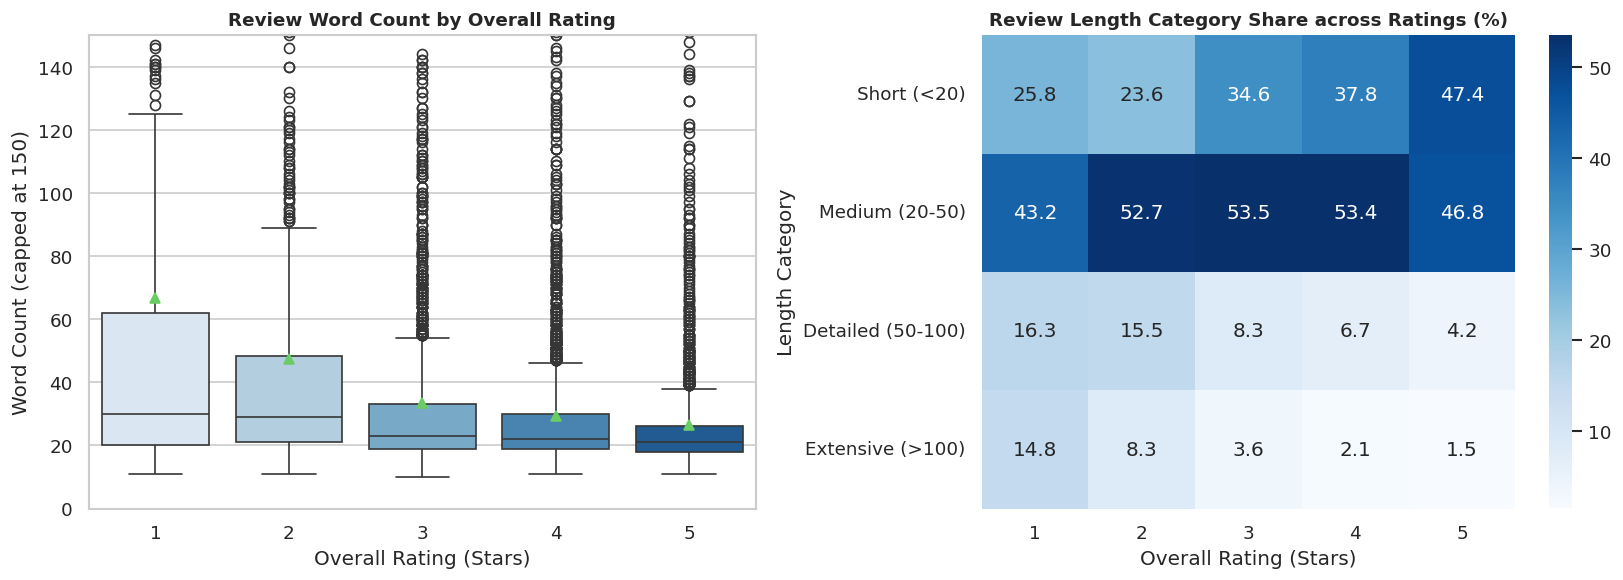

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Word count distribution by rating
sns.boxplot(data=df, x='ratingOverall', y='word_count', ax=ax1, palette='Blues', showmeans=True)
ax1.set_ylim(0, 150)
ax1.set_title("Review Word Count by Overall Rating", fontsize=11, fontweight='bold')
ax1.set_xlabel("Overall Rating (Stars)")
ax1.set_ylabel("Word Count (capped at 150)")

# Length category breakdown
length_rating_ct = pd.crosstab(df['length_category'], df['ratingOverall'], normalize='columns') * 100
sns.heatmap(length_rating_ct, annot=True, fmt='.1f', cmap='Blues', ax=ax2)
ax2.set_title("Review Length Category Share across Ratings (%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Overall Rating (Stars)")
ax2.set_ylabel("Length Category")

plt.tight_layout()
plt.show()

> **WHAT DID WE FIND?**  
> - **Verbosity Asymmetry:** 1-star reviews have a median word count of **38 words** compared to **20 words** for 5-star reviews.
> - Detailed and extensive reviews (>50 words) account for over **35% of 1-star reviews**, but only **16% of 5-star reviews**.
>
> **WHY DOES IT MATTER?**  
> Dissatisfied employees spend significantly more effort articulating specific workplace pain points. In NLP topic modeling, this means negative themes will have a richer lexical footprint than positive themes.
>
> **WHAT IS THE LIMITATION?**  
> High word count indicates passionate engagement, which may reflect extreme outliers rather than the silent majority of employees.

---
### Section 5: Recommendation & CEO Approval Behavior

> **WHAT ARE WE DOING?**  
> We analyze the relationship between overall ratings, peer recommendations (`ratingRecommendToFriend`), and CEO approval (`ratingCeo`).
>
> **WHY ARE WE DOING IT?**  
> These categorical flags provide additional validation of employee loyalty and leadership confidence.
>
> **WHAT SHOULD WE EXPECT?**  
> Recommendation rates should correlate strongly with overall ratings, with a sharp drop at 3 stars.

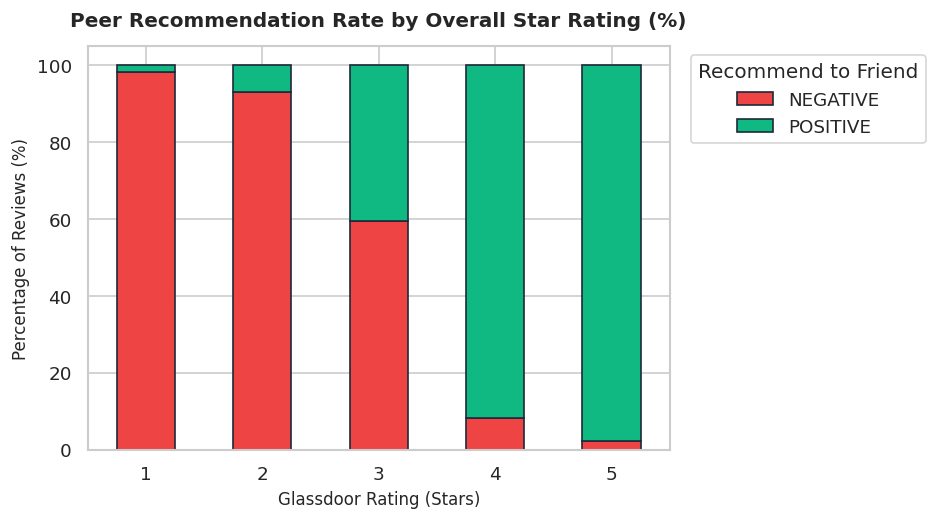

In [5]:
sub_flags = df[df['ratingRecommendToFriend'].notnull() & (df['ratingRecommendToFriend'] != '')]
rec_ct = pd.crosstab(sub_flags['ratingOverall'], sub_flags['ratingRecommendToFriend'], normalize='index') * 100

plt.figure(figsize=(8, 4.5))
rec_ct.plot(kind='bar', stacked=True, color=['#EF4444', '#10B981'], edgecolor='#1E293B', ax=plt.gca())
plt.title("Peer Recommendation Rate by Overall Star Rating (%)", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Glassdoor Rating (Stars)", fontsize=10)
plt.ylabel("Percentage of Reviews (%)", fontsize=10)
plt.legend(title="Recommend to Friend", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
### Section 6: Saving Processed Analysis Dataset

> **WHAT ARE WE DOING?**  
> We export the validated, cleaned dataset to `data/processed/glassdoor_cleaned.csv`.
>
> **WHY ARE WE DOING IT?**  
> Downstream notebooks (sentiment analysis, NLP, topic modeling) can now ingest a unified, reliable baseline without repeating cleaning operations.

In [6]:
output_path = DATA_PROCESSED / "glassdoor_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"✅ Successfully exported cleaned dataset to: {output_path.name}")
print(f"Final Cleaned Dataset Dimensions: {df.shape[0]:,} rows | {df.shape[1]} columns")

✅ Successfully exported cleaned dataset to: glassdoor_cleaned.csv
Final Cleaned Dataset Dimensions: 8,785 rows | 38 columns
